# Solving 1D Chemical Diffusion: Solvers, Timings & Convergence

In this tutorial, we will learn how to:
1. Define a 1D chemical species diffusion problem using **Soft Potato**'s `DiffusionProblem`.
2. Solve the diffusion equation using four distinct numerical algorithms:
   - **`scipy_ivp`**: Method of Lines with SciPy's stiff adaptive ODE integrator (`Radau`).
   - **`crank_nicolson`**: 2nd-order unconditionally stable Crank-Nicolson finite difference.
   - **`implicit`**: Unconditionally stable Backward-Time Central-Space (BTCS).
   - **`explicit`**: Forward-Time Central-Space (FTCS) with CFL stability enforcement.
3. Compare all four solvers against the **exact analytical solution** on a spatial plot.
4. **Benchmark execution time** across solvers on fine spatial grids, examining how the CFL condition impacts computational cost.
5. **Analyze numerical convergence**: Plot the maximum error as a function of the number of time steps ($N_{\text{steps}}$) to compare convergence rates and stability boundaries.

---

## 1. Physical & Mathematical Formulation

We consider the 1D diffusion of a chemical species $c(x, t)$ governed by Fick's Second Law:

$$\frac{\partial c}{\partial t} = D \frac{\partial^2 c}{\partial x^2}$$

over the spatial domain $x \in [0, L]$ and time $t \in [0, t_{\text{final}}]$.

We enforce homogeneous Dirichlet boundary conditions (e.g. constant reservoir or reactive sink):
$$c(0, t) = 0, \quad c(L, t) = 0$$

with a sinusoidal initial concentration profile:
$$c(x, 0) = \sin\left(\frac{\pi x}{L}\right)$$

The **exact analytical solution** to this initial-boundary value problem is:
$$c_{\text{exact}}(x, t) = \sin\left(\frac{\pi x}{L}\right) \exp\left(-D \frac{\pi^2}{L^2} t\right)$$

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import softpotato as sp
from softpotato.solver import (
    DiffusionProblem,
    DirichletBC,
    get_solver,
    list_solvers,
)

print(f"Soft Potato Version: {sp.__version__}")
print(f"Available Solvers: {list_solvers()}")

Soft Potato Version: 3.0.0a1
Available Solvers: ['btcs', 'crank-nicolson', 'crank_nicolson', 'explicit', 'ftcs', 'implicit', 'scipy_ivp', 'solve_ivp']


## 2. Defining the Diffusion Problem

We discretize the domain $L = 1.0\text{ cm}$ with $N_x = 51$ grid points, and set diffusion coefficient $D = 0.05\text{ cm}^2/\text{s}$.

In [2]:
# Domain parameters
L = 1.0  # Domain length (cm)
D = 0.05  # Diffusion coefficient (cm²/s)
Nx = 51  # Number of spatial grid points
x = np.linspace(0.0, L, Nx)

# Problem definition
problem = DiffusionProblem(
    grid=x,
    diffusivity={"c": D},
    boundary_conditions={"c": (DirichletBC(0.0), DirichletBC(0.0))},
    initial_conditions={"c": lambda x_pts: np.sin(np.pi * x_pts / L)},
)

print(f"Grid spacing dx: {problem.dx:.4f} cm")
print(f"Species: {problem.species}")

Grid spacing dx: 0.0200 cm
Species: ['c']


## 3. Solving with Multiple Numerical Engines

All solvers in Soft Potato share the identical `solve(problem, t_span, t_eval)` interface.
We integrate from $t = 0.0$ to $t = 0.5$ seconds, recording the solution at 11 evenly spaced time points.

In [3]:
# Time integration span
t_span = (0.0, 0.5)
t_eval = np.linspace(0.0, 0.5, 11)

# Instantiate the solvers
solvers = {
    "SciPy IVP (Radau)": get_solver("scipy_ivp", method="Radau"),
    "Crank-Nicolson": get_solver("crank_nicolson", dt=0.01),
    "Implicit (BTCS)": get_solver("implicit", dt=0.01),
    "Explicit (FTCS)": get_solver("explicit", dt=1e-4),
}

# Run all simulations
results = {}
for name, solver in solvers.items():
    results[name] = solver.solve(problem, t_span=t_span, t_eval=t_eval)
    print(
        f"[{name}] Success: {results[name].success}, shape: {results[name]['c'].shape}"
    )

[SciPy IVP (Radau)] Success: True, shape: (11, 51)
[Crank-Nicolson] Success: True, shape: (11, 51)
[Implicit (BTCS)] Success: True, shape: (11, 51)
[Explicit (FTCS)] Success: True, shape: (11, 51)


## 4. Comparing Concentration Profiles Across Solvers

We evaluate the exact analytical solution:
$$c_{\text{exact}}(x, t) = \sin\left(\frac{\pi x}{L}\right) \exp\left(-D \frac{\pi^2}{L^2} t\right)$$
and compare the profiles computed by each solver against the analytical solution at multiple time steps.

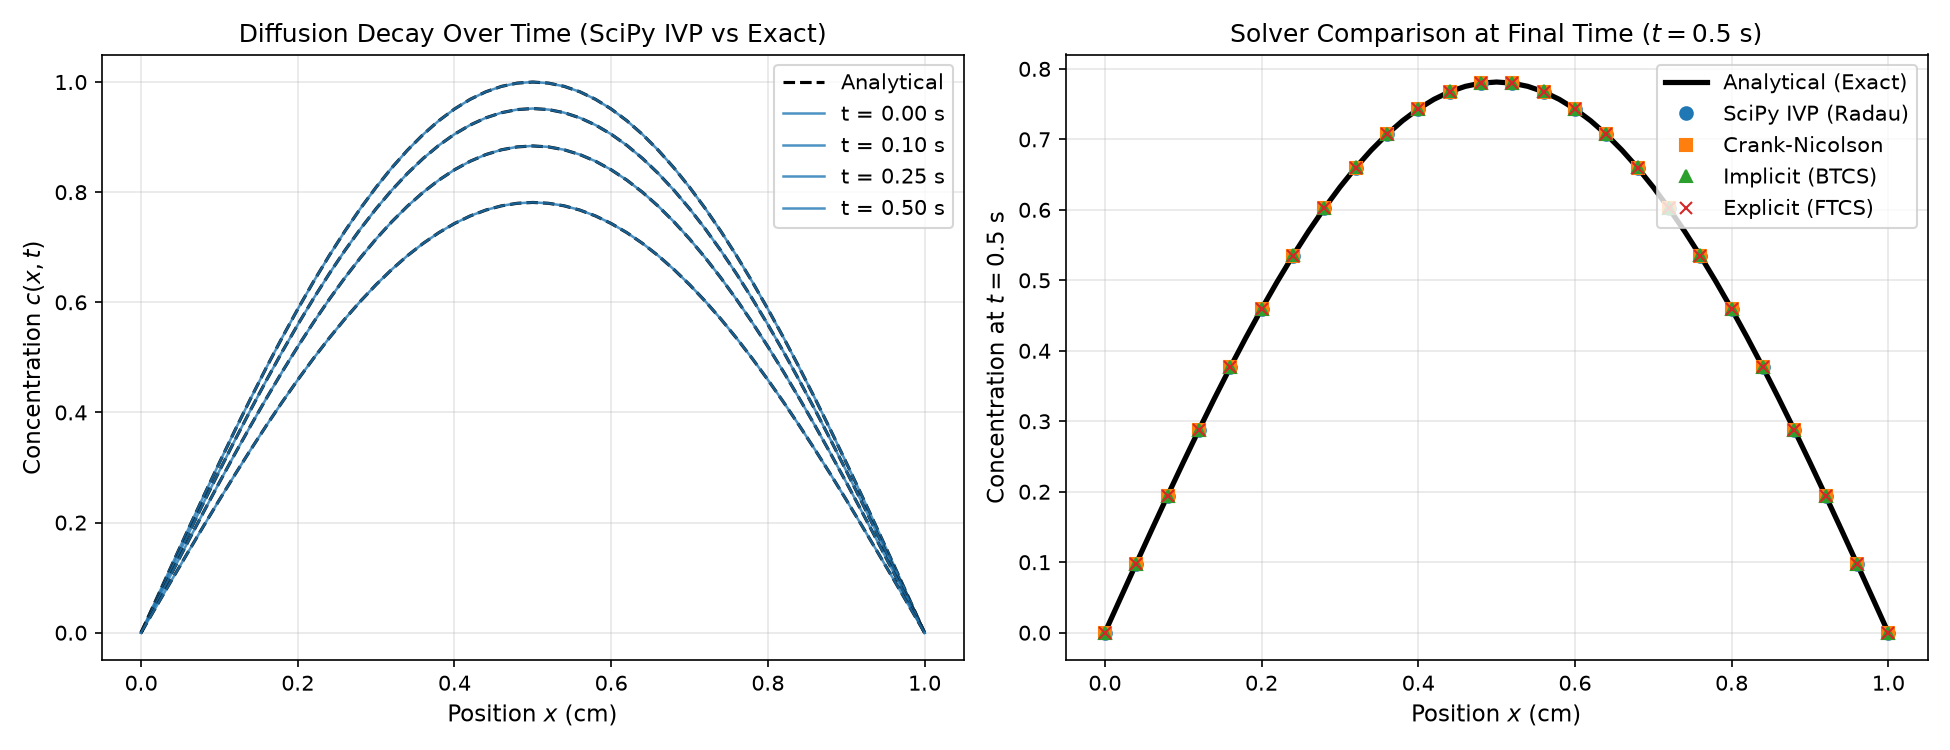

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Time evolution of concentration profile
target_indices = [0, 2, 5, 10]
for idx in target_indices:
    ti = t_eval[idx]
    c_exact = np.sin(np.pi * x / L) * np.exp(-D * (np.pi / L) ** 2 * ti)
    axes[0].plot(x, c_exact, "k--", lw=1.5, label="Analytical" if idx == 0 else "")
    axes[0].plot(
        x,
        results["SciPy IVP (Radau)"]["c"][idx, :],
        "-",
        lw=1.2,
        label=f"t = {ti:.2f} s",
    )

axes[0].set_xlabel("Position $x$ (cm)", fontsize=11)
axes[0].set_ylabel("Concentration $c(x, t)$", fontsize=11)
axes[0].set_title("Diffusion Decay Over Time (SciPy IVP vs Exact)", fontsize=12)
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Right: Direct comparison of all 4 numerical schemes at final time t = 0.5 s
ti_final = t_eval[-1]
c_exact_final = np.sin(np.pi * x / L) * np.exp(-D * (np.pi / L) ** 2 * ti_final)
axes[1].plot(x, c_exact_final, "k-", lw=2.5, label="Analytical (Exact)")

markers = ["o", "s", "^", "x"]
for (name, res), marker in zip(results.items(), markers):
    axes[1].plot(
        x[::2], res["c"][-1, :][::2], marker=marker, ls="None", markersize=6, label=name
    )

axes[1].set_xlabel("Position $x$ (cm)", fontsize=11)
axes[1].set_ylabel("Concentration at $t = 0.5$ s", fontsize=11)
axes[1].set_title("Solver Comparison at Final Time ($t = 0.5$ s)", fontsize=12)
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Execution Time Benchmark & Number of Steps

As spatial resolution increases ($\Delta x \to 0$), the stability criterion of the **explicit** scheme becomes severe:

$$\Delta t \le \frac{\Delta x^2}{2 D_{\max}}$$

Halving $\Delta x$ forces a **$4\times$ reduction in $\Delta t$**, requiring drastically more steps.
In contrast, **implicit** (BTCS), **Crank-Nicolson**, and **SciPy IVP** are unconditionally stable and can take much larger time steps.

To demonstrate this difference, we increase the grid to $N_x = 201$ points ($\Delta x = 0.005\text{ cm}$) and integrate up to $t_{\text{final}} = 1.0\text{ s}$.

In [5]:
# Higher resolution grid: Nx = 201 (dx = 0.005 cm)
Nx_bench = 201
x_bench = np.linspace(0.0, 1.0, Nx_bench)
dx_bench = x_bench[1] - x_bench[0]
cfl_dt = (dx_bench**2) / (2.0 * D)

print(f"Nx = {Nx_bench}, dx = {dx_bench:.4e} cm")
print(f"Explicit CFL maximum stable dt: {cfl_dt:.4e} s")

problem_bench = DiffusionProblem(
    grid=x_bench,
    diffusivity={"c": D},
    boundary_conditions={"c": (DirichletBC(0.0), DirichletBC(0.0))},
    initial_conditions={"c": lambda x_pts: np.sin(np.pi * x_pts / L)},
)

# Exact analytical solution at t = 1.0 s for error comparison
c_exact_bench = np.sin(np.pi * x_bench / L) * np.exp(-D * (np.pi / L) ** 2 * 1.0)

bench_solvers = [
    ("SciPy IVP (Radau)", "scipy_ivp", {"method": "Radau"}),
    ("Crank-Nicolson (dt=0.01)", "crank_nicolson", {"dt": 0.01}),
    ("Implicit BTCS (dt=0.01)", "implicit", {"dt": 0.01}),
    (
        "Explicit FTCS (CFL-safe)",
        "explicit",
        {},
    ),  # automatically chooses CFL-safe sub-step
]

bench_names, bench_times, bench_steps, bench_errors = [], [], [], []
for label, sname, skwargs in bench_solvers:
    s = get_solver(sname, **skwargs)
    # Warmup and timing
    t0 = time.perf_counter()
    res = s.solve(problem_bench, t_span=(0.0, 1.0), t_eval=np.linspace(0, 1, 11))
    elapsed_ms = (time.perf_counter() - t0) * 1000.0

    err = np.max(np.abs(res["c"][-1, :] - c_exact_bench))
    n_steps = (
        res.raw_output.nfev
        if sname == "scipy_ivp"
        else (100 if "dt" in skwargs else int(np.ceil(1.0 / (0.45 * cfl_dt))))
    )

    bench_names.append(label)
    bench_times.append(elapsed_ms)
    bench_steps.append(n_steps)
    bench_errors.append(err)
    print(
        f"{label:26s} | Time: {elapsed_ms:6.2f} ms | Steps/Evals: {n_steps:5d} | Max Err: {err:.2e}"
    )

Nx = 201, dx = 5.0000e-03 cm
Explicit CFL maximum stable dt: 2.5000e-04 s
SciPy IVP (Radau)          | Time:  18.35 ms | Steps/Evals:    57 | Max Err: 6.19e-06
Crank-Nicolson (dt=0.01)   | Time:   5.53 ms | Steps/Evals:   100 | Max Err: 5.60e-06
Implicit BTCS (dt=0.01)    | Time:   4.68 ms | Steps/Evals:   100 | Max Err: 7.34e-04
Explicit FTCS (CFL-safe)   | Time:  58.98 ms | Steps/Evals:  8889 | Max Err: 2.17e-06


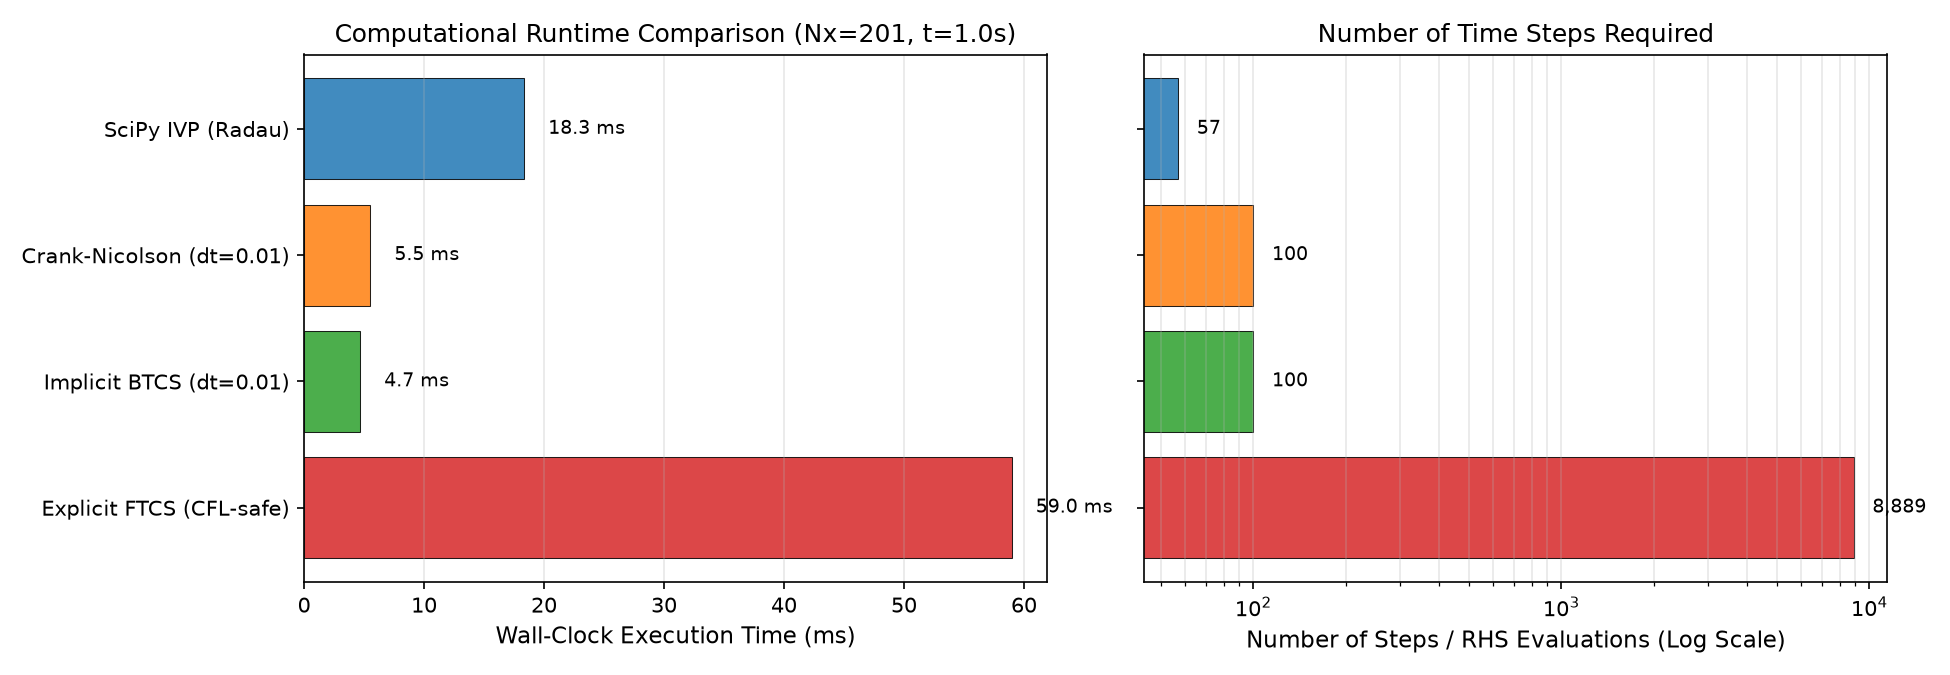

In [6]:
fig, (ax_time, ax_steps) = plt.subplots(1, 2, figsize=(13, 4.5))
bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
y_pos = np.arange(len(bench_names))

# Left: Execution time
bars1 = ax_time.barh(y_pos, bench_times, color=bar_colors, alpha=0.85)
ax_time.set_yticks(y_pos)
ax_time.set_yticklabels(bench_names)
ax_time.invert_yaxis()
ax_time.set_xlabel("Wall-Clock Execution Time (ms)", fontsize=11)
ax_time.set_title("Computational Runtime Comparison (Nx=201, t=1.0s)", fontsize=12)
ax_time.grid(True, axis="x", alpha=0.3)

for bar in bars1:
    ax_time.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f} ms",
        va="center",
    )

# Right: Number of steps (log scale)
bars2 = ax_steps.barh(y_pos, bench_steps, color=bar_colors, alpha=0.85)
ax_steps.set_yticks(y_pos)
ax_steps.set_yticklabels([""] * len(bench_names))
ax_steps.invert_yaxis()
ax_steps.set_xscale("log")
ax_steps.set_xlabel("Number of Steps / RHS Evaluations (Log Scale)", fontsize=11)
ax_steps.set_title("Number of Time Steps Required", fontsize=12)
ax_steps.grid(True, which="both", axis="x", alpha=0.3)

for bar, n_st in zip(bars2, bench_steps):
    ax_steps.text(
        n_st * 1.15, bar.get_y() + bar.get_height() / 2, f"{n_st:,}", va="center"
    )

plt.tight_layout()
plt.show()

## 6. Numerical Convergence: Error vs. Number of Time Steps

To analyze how quickly each numerical algorithm converges as the time-stepping grid is refined, we measure the maximum error at $t = 0.5\text{ s}$:

$$L_\infty = \max_{x} |c_{\text{numerical}}(x, t_{\text{final}}) - c_{\text{exact}}(x, t_{\text{final}})|$$

as a function of the total number of time steps $N_{\text{steps}}$.

Key theoretical expectations:
- **Crank-Nicolson**: Second-order accurate in time $\mathcal{O}(\Delta t^2) = \mathcal{O}(1 / N_{\text{steps}}^2)$. Rapidly converges to the spatial discretization floor in very few steps ($N_{\text{steps}} \approx 20$).
- **Implicit (BTCS)**: First-order accurate in time $\mathcal{O}(\Delta t) = \mathcal{O}(1 / N_{\text{steps}})$. Unconditionally stable for any $N_{\text{steps}}$, with error steadily decreasing.
- **Explicit (FTCS)**: Conditionally stable. Requires $N_{\text{steps}} \ge N_{\text{CFL}} \approx 500$; any attempt to take fewer steps violates the CFL limit.
- **SciPy IVP (Radau)**: Uses high-order adaptive step sizing; achieves near-optimal error with very few function evaluations ($N_{\text{evals}} \approx 20\text{--}50$).

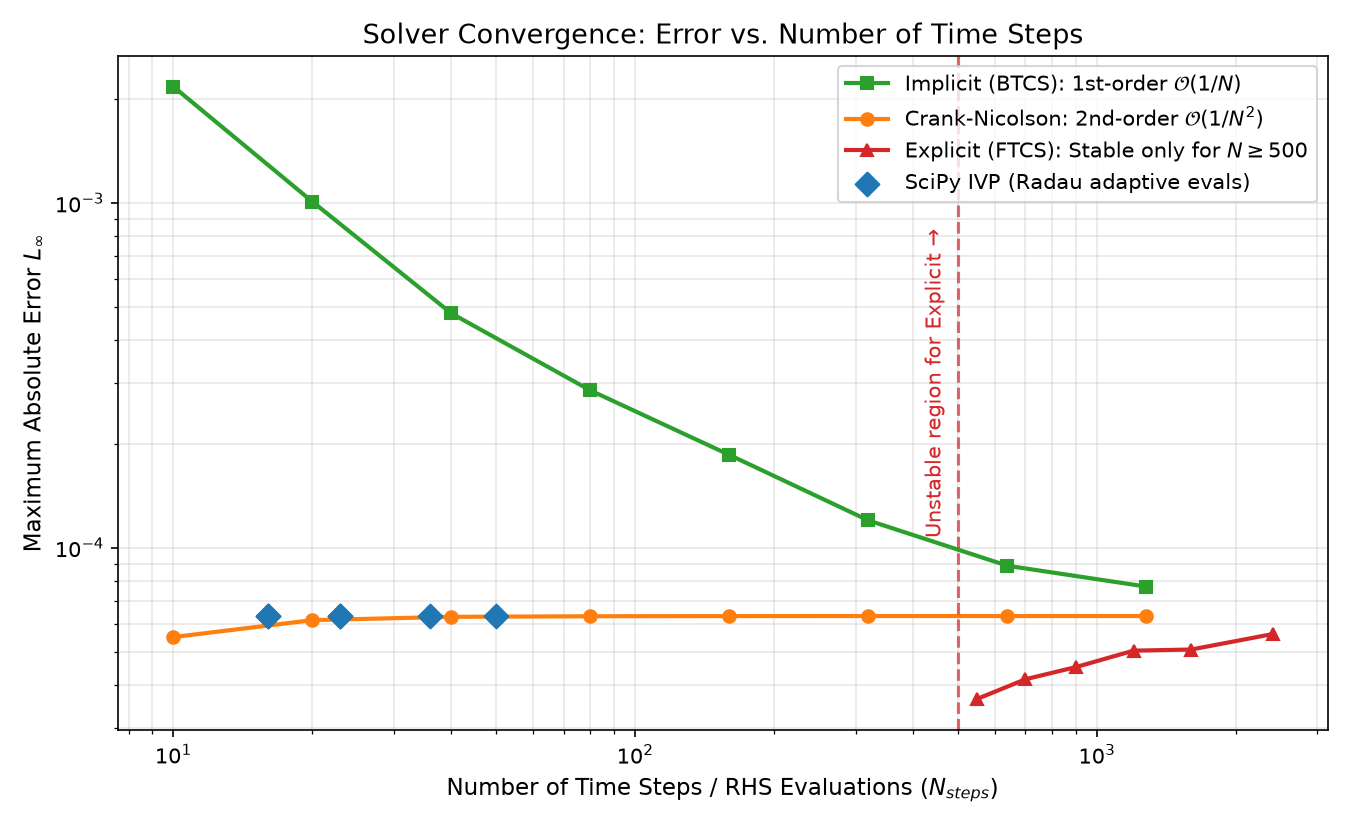

In [7]:
# Range of time step counts
step_counts_implicit = [10, 20, 40, 80, 160, 320, 640, 1280]
step_counts_explicit = [550, 700, 900, 1200, 1600, 2400]

errors_btcs, errors_cn, errors_ftcs = [], [], []

for n_st in step_counts_implicit:
    dt = 0.5 / n_st
    r_btcs = get_solver("implicit", dt=dt).solve(problem, t_span=(0.0, 0.5))
    errors_btcs.append(np.max(np.abs(r_btcs["c"][-1, :] - c_exact_final)))

    r_cn = get_solver("crank_nicolson", dt=dt).solve(problem, t_span=(0.0, 0.5))
    errors_cn.append(np.max(np.abs(r_cn["c"][-1, :] - c_exact_final)))

for n_st in step_counts_explicit:
    dt = 0.5 / n_st
    r_ftcs = get_solver("explicit", dt=dt).solve(problem, t_span=(0.0, 0.5))
    errors_ftcs.append(np.max(np.abs(r_ftcs["c"][-1, :] - c_exact_final)))

# SciPy IVP error vs internal evaluations across tolerances
scipy_steps, scipy_errors = [], []
for tol in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]:
    res_scipy = get_solver(
        "scipy_ivp", method="Radau", rtol=tol, atol=tol * 1e-2
    ).solve(problem, t_span=(0.0, 0.5))
    scipy_steps.append(res_scipy.raw_output.nfev)
    scipy_errors.append(np.max(np.abs(res_scipy["c"][-1, :] - c_exact_final)))

# Plot convergence curves
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(
    step_counts_implicit,
    errors_btcs,
    "s-",
    color="#2ca02c",
    lw=2,
    label=r"Implicit (BTCS): 1st-order $\mathcal{O}(1/N)$",
)
ax.loglog(
    step_counts_implicit,
    errors_cn,
    "o-",
    color="#ff7f0e",
    lw=2,
    label=r"Crank-Nicolson: 2nd-order $\mathcal{O}(1/N^2)$",
)
ax.loglog(
    step_counts_explicit,
    errors_ftcs,
    "^-",
    color="#d62728",
    lw=2,
    label=r"Explicit (FTCS): CFL stable for $N \geq 500$",
)
ax.scatter(
    scipy_steps,
    scipy_errors,
    marker="D",
    s=65,
    color="#1f77b4",
    zorder=5,
    label="SciPy IVP (Radau adaptive evals)",
)

# Mark Explicit CFL limit
ax.axvline(500, color="#d62728", ls="--", alpha=0.7)
ax.text(
    470,
    3e-4,
    "Unstable region for Explicit →",
    color="#d62728",
    rotation=90,
    va="center",
    ha="right",
    fontsize=10,
)

ax.set_xlabel("Number of Time Steps / RHS Evaluations ($N_{steps}$)", fontsize=11)
ax.set_ylabel(r"Maximum Absolute Error $L_\infty$", fontsize=11)
ax.set_title("Solver Convergence: Error vs. Number of Time Steps", fontsize=13)
ax.legend(loc="upper right", frameon=True, fontsize=10)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary and Selection Guide

| Solver | Stability | Convergence Rate | Typical Steps Required | Execution Time | Recommended For |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **`crank_nicolson`** | Unconditionally stable | $\mathcal{O}(\Delta t^2)$ (fastest) | **20 – 100** | **Fastest (tridiagonal)** | Accurate transient diffusion sweeps (voltammetry, chronoamperometry) |
| **`implicit`** (BTCS) | Unconditionally stable | $\mathcal{O}(\Delta t)$ | **50 – 500** | **Fast (tridiagonal)** | Monotonic, non-oscillatory decay with very large time steps |
| **`scipy_ivp`** (Radau) | Unconditionally stable (L-stable) | High-order adaptive | **20 – 60 (evaluations)** | **Moderate** | Stiff reaction-diffusion, non-linear reaction kinetics, multi-species coupling |
| **`explicit`** (FTCS) | Conditionally stable ($N \ge N_{\text{CFL}}$) | $\mathcal{O}(\Delta t)$ | **> 1,000 – 10,000** | **Slowest on fine grids** | Coarse meshes, rapid prototyping, educational demonstrations |